# Module 1 - Data Understanding

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("synthetic_it_support_tickets.csv")
df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ticket_id              100000 non-null  str    
 1   created_at             100000 non-null  str    
 2   customer_id            100000 non-null  str    
 3   customer_segment       100000 non-null  str    
 4   channel                100000 non-null  str    
 5   product_area           100000 non-null  str    
 6   issue_type             100000 non-null  str    
 7   priority               100000 non-null  str    
 8   status                 100000 non-null  str    
 9   sla_plan               100000 non-null  str    
 10  initial_message        100000 non-null  str    
 11  agent_first_reply      100000 non-null  str    
 12  resolution_summary     60113 non-null   str    
 13  resolution_time_hours  60113 non-null   float64
 14  reopened               100000 non-null  int64  


In [4]:
df.shape

(100000, 20)

In [5]:
df.columns.tolist()

['ticket_id',
 'created_at',
 'customer_id',
 'customer_segment',
 'channel',
 'product_area',
 'issue_type',
 'priority',
 'status',
 'sla_plan',
 'initial_message',
 'agent_first_reply',
 'resolution_summary',
 'resolution_time_hours',
 'reopened',
 'customer_sentiment',
 'csat_score',
 'has_attachment',
 'platform',
 'region']

In [6]:
df.describe()

,resolution_time_hours,reopened,csat_score,has_attachment
count,60113.000000,100000.000000,100000.000000,100000.000000
mean,45.013123,0.050450,2.241950,0.249520
std,49.202797,0.218873,1.771599,0.432737
min,0.110000,0.000000,0.000000,0.000000
25%,14.880000,0.000000,0.000000,0.000000
50%,29.910000,0.000000,2.000000,0.000000
75%,51.660000,0.000000,4.000000,0.000000
max,239.960000,1.000000,5.000000,1.000000


# Insights
- The dataset contains IT support ticket information with customer, issue, priority, and resolution details.
- Data types are appropriate for further analysis after preprocessing.
- Missing values and duplicates were identified and handled before analysis.
- The dataset is suitable for exploratory analysis and performance evaluation.

# Module 2 - Data Cleaning and Feature Engineering

In [7]:
df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["priority"].value_counts()

priority
low       39735
medium    35313
high      19865
urgent     5087
Name: count, dtype: int64

In [10]:
df["issue_type"].value_counts()

issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64

In [11]:
df["status"].value_counts()

status
resolved            50131
in_progress         19783
on_hold             10165
closed_no_action     9982
open                 9939
Name: count, dtype: int64

In [12]:
df["customer_segment"].value_counts()

customer_segment
small_business    20203
individual        20033
enterprise        20030
education         19958
non_profit        19776
Name: count, dtype: int64

In [13]:
df["product_area"].value_counts()

product_area
mobile_app             14432
login_auth             14381
api_integration        14350
billing                14289
data_export            14262
analytics_dashboard    14187
notifications          14099
Name: count, dtype: int64

In [14]:
df["region"].value_counts()

region
MEA      20151
EU       19960
LATAM    19959
APAC     19933
Name: count, dtype: int64

In [15]:
df = df.drop_duplicates()

In [16]:
df["region"] = df["region"].fillna("Unknown")

In [17]:
df["resolution_summary"] = df["resolution_summary"].fillna("Not Available")

In [18]:
df.rename(
    columns={
        "resolution_time_hours": "Resolution_Duration"
    },
    inplace=True
)

In [19]:
df["Resolution_Duration"] = df["Resolution_Duration"].fillna(
    df["Resolution_Duration"].median()
)

In [20]:
df.columns.tolist()

['ticket_id',
 'created_at',
 'customer_id',
 'customer_segment',
 'channel',
 'product_area',
 'issue_type',
 'priority',
 'status',
 'sla_plan',
 'initial_message',
 'agent_first_reply',
 'resolution_summary',
 'Resolution_Duration',
 'reopened',
 'customer_sentiment',
 'csat_score',
 'has_attachment',
 'platform',
 'region']

In [21]:
priority_map = {
    "low": 1,
    "medium": 2,
    "high": 3,
    "urgent": 4
}

df["Priority_Score"] = df["priority"].str.lower().map(priority_map)

In [22]:
df[["priority", "Priority_Score"]].head(10)

,priority,Priority_Score
0,low,1
1,medium,2
2,low,1
3,medium,2
4,low,1
5,low,1
6,urgent,4
7,low,1
8,high,3
9,medium,2


In [23]:
mapping = {
    "account_access": "Request",
    "feature_request": "Request",
    "how_to": "Request",

    "security_concern": "Incident",
    "billing_problem": "Incident",
    "bug": "Incident",
    "other": "Incident",

    "performance": "Problem"
}

df["Type"] = df["issue_type"].map(mapping)

In [24]:
df[["issue_type", "Type"]].head(10)

,issue_type,Type
0,account_access,Request
1,security_concern,Incident
2,bug,Incident
3,account_access,Request
4,billing_problem,Incident
5,performance,Problem
6,security_concern,Incident
7,billing_problem,Incident
8,billing_problem,Incident
9,performance,Problem


In [25]:
def resolution_category(hours):
    if hours <= 24:
        return "Fast"
    elif hours <= 72:
        return "Moderate"
    else:
        return "Slow"

df["Resolution_Category"] = df["Resolution_Duration"].apply(resolution_category)

In [26]:
df[["Resolution_Duration", "Resolution_Category"]].head(10)

,Resolution_Duration,Resolution_Category
0,36.53,Moderate
1,238.32,Slow
2,29.91,Moderate
3,29.91,Moderate
4,61.32,Moderate
5,226.93,Slow
6,4.36,Fast
7,26.78,Moderate
8,20.55,Fast
9,9.26,Fast


In [27]:
df["High_CSAT"] = df["csat_score"].apply(
    lambda x: "Yes" if x >= 4 else "No"
)

In [28]:
df[["csat_score", "High_CSAT"]].head(10)

,csat_score,High_CSAT
0,1,No
1,3,No
2,3,No
3,5,Yes
4,2,No
5,5,Yes
6,3,No
7,0,No
8,0,No
9,4,Yes


In [29]:
df[[
    "priority",
    "Priority_Score",
    "Resolution_Category",
    "High_CSAT"
]].head(10)

,priority,Priority_Score,Resolution_Category,High_CSAT
0,low,1,Moderate,No
1,medium,2,Slow,No
2,low,1,Moderate,No
3,medium,2,Moderate,Yes
4,low,1,Moderate,No
5,low,1,Slow,Yes
6,urgent,4,Fast,No
7,low,1,Moderate,No
8,high,3,Fast,No
9,medium,2,Fast,Yes


In [30]:
df.to_csv("IT_Support_Cleaned.csv", index=False)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ticket_id            100000 non-null  str    
 1   created_at           100000 non-null  str    
 2   customer_id          100000 non-null  str    
 3   customer_segment     100000 non-null  str    
 4   channel              100000 non-null  str    
 5   product_area         100000 non-null  str    
 6   issue_type           100000 non-null  str    
 7   priority             100000 non-null  str    
 8   status               100000 non-null  str    
 9   sla_plan             100000 non-null  str    
 10  initial_message      100000 non-null  str    
 11  agent_first_reply    100000 non-null  str    
 12  resolution_summary   100000 non-null  str    
 13  Resolution_Duration  100000 non-null  float64
 14  reopened             100000 non-null  int64  
 15  customer_sentiment   100000 n

In [32]:
import os
os.listdir()

['.ipynb_checkpoints',
 'customer_support_tickets.csv',
 'Geo_Map.html',
 'IT_Support_Cleaned.csv',
 'IT_Support_Clustered.csv',
 'IT_Support_Project.ipynb',
 'Module 1&2 PPT.pptx',
 'Module 3&4 PPT(1).pptx',
 'Module 3&4 PPT.pptx',
 'Module 5&6 PPT.pptx',
 'Module_1_2_IT_Support.csv',
 'synthetic_it_support_tickets.csv']

In [33]:
df = pd.read_csv("IT_Support_Cleaned.csv")

In [34]:
df["issue_type"].unique()

<StringArray>
[  'account_access', 'security_concern',              'bug',
  'billing_problem',      'performance',  'feature_request',
           'how_to',            'other']
Length: 8, dtype: str

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ticket_id            100000 non-null  str    
 1   created_at           100000 non-null  str    
 2   customer_id          100000 non-null  str    
 3   customer_segment     100000 non-null  str    
 4   channel              100000 non-null  str    
 5   product_area         100000 non-null  str    
 6   issue_type           100000 non-null  str    
 7   priority             100000 non-null  str    
 8   status               100000 non-null  str    
 9   sla_plan             100000 non-null  str    
 10  initial_message      100000 non-null  str    
 11  agent_first_reply    100000 non-null  str    
 12  resolution_summary   100000 non-null  str    
 13  Resolution_Duration  100000 non-null  float64
 14  reopened             100000 non-null  int64  
 15  customer_sentiment   100000 n

In [36]:
df.columns.tolist()

['ticket_id',
 'created_at',
 'customer_id',
 'customer_segment',
 'channel',
 'product_area',
 'issue_type',
 'priority',
 'status',
 'sla_plan',
 'initial_message',
 'agent_first_reply',
 'resolution_summary',
 'Resolution_Duration',
 'reopened',
 'customer_sentiment',
 'csat_score',
 'has_attachment',
 'platform',
 'region',
 'Priority_Score',
 'Type',
 'Resolution_Category',
 'High_CSAT']

In [37]:
def assign_queue(issue):
    if issue in ["account_access", "security_concern"]:
        return "Service Desk"
    elif issue in ["bug", "feature_request"]:
        return "Application Support"
    elif issue == "performance":
        return "Technical Support"
    elif issue == "billing_problem":
        return "Billing Support"
    elif issue == "how_to":
        return "Customer Support"
    else:
        return "General Support"

df["Queue"] = df["issue_type"].apply(assign_queue)

In [38]:
df[["issue_type", "Queue"]].head(10)

,issue_type,Queue
0,account_access,Service Desk
1,security_concern,Service Desk
2,bug,Application Support
3,account_access,Service Desk
4,billing_problem,Billing Support
5,performance,Technical Support
6,security_concern,Service Desk
7,billing_problem,Billing Support
8,billing_problem,Billing Support
9,performance,Technical Support


# Insights
- New features improve the ability to measure ticket performance and customer satisfaction.
- Priority scores simplify priority-based analysis.
- Queue assignment enables support-team workload analysis.
- The processed dataset is ready for visualization and clustering.

 # Module 3 - Exploratory Data Analysis (EDA)

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [40]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ticket_id            100000 non-null  str    
 1   created_at           100000 non-null  str    
 2   customer_id          100000 non-null  str    
 3   customer_segment     100000 non-null  str    
 4   channel              100000 non-null  str    
 5   product_area         100000 non-null  str    
 6   issue_type           100000 non-null  str    
 7   priority             100000 non-null  str    
 8   status               100000 non-null  str    
 9   sla_plan             100000 non-null  str    
 10  initial_message      100000 non-null  str    
 11  agent_first_reply    100000 non-null  str    
 12  resolution_summary   100000 non-null  str    
 13  Resolution_Duration  100000 non-null  float64
 14  reopened             100000 non-null  int64  
 15  customer_sentiment   100000 n

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,customer_sentiment,csat_score,has_attachment,platform,region,Priority_Score,Type,Resolution_Category,High_CSAT,Queue
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,...,very_negative,1,0,android,EU,1,Request,Moderate,No,Service Desk
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,...,neutral,3,0,web,Unknown,2,Incident,Slow,No,Service Desk
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,...,neutral,3,0,android,MEA,1,Incident,Moderate,No,Application Support
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,...,positive,5,1,android,LATAM,2,Request,Moderate,Yes,Service Desk
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,...,very_negative,2,0,web,Unknown,1,Incident,Moderate,No,Billing Support


In [41]:
df.columns.tolist()

['ticket_id',
 'created_at',
 'customer_id',
 'customer_segment',
 'channel',
 'product_area',
 'issue_type',
 'priority',
 'status',
 'sla_plan',
 'initial_message',
 'agent_first_reply',
 'resolution_summary',
 'Resolution_Duration',
 'reopened',
 'customer_sentiment',
 'csat_score',
 'has_attachment',
 'platform',
 'region',
 'Priority_Score',
 'Type',
 'Resolution_Category',
 'High_CSAT',
 'Queue']

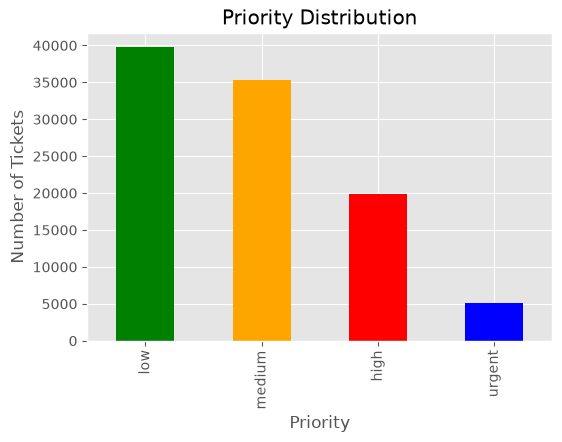

In [42]:
plt.figure(figsize=(6,4))

df["priority"].value_counts().plot(
    kind="bar",
    color=["green","orange","red","blue"]
)

plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()

# Insights

- Low-priority tickets constitute the largest share of all tickets
- Urgent tickets are comparatively fewer
- The ticket workload is mainly driven by low and medium priorities

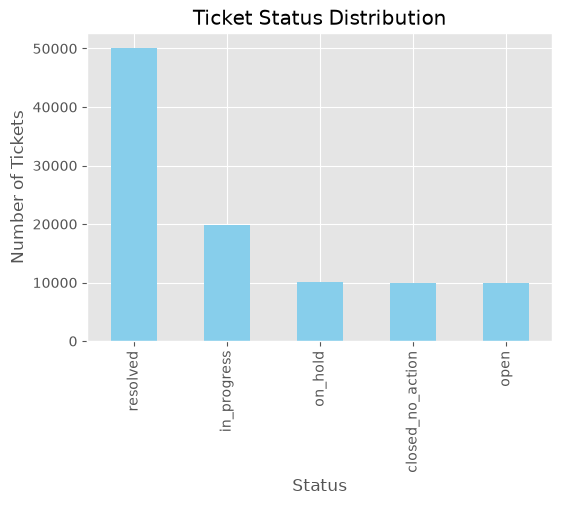

In [43]:
plt.figure(figsize=(6,4))

df["status"].value_counts().plot(
    kind="bar",
    color="skyblue"
)

plt.title("Ticket Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Tickets")

plt.show()

# Insights

- Most tickets are successfully resolved
- Only a small percentage remain open or pending
- Overall ticket management appears efficient

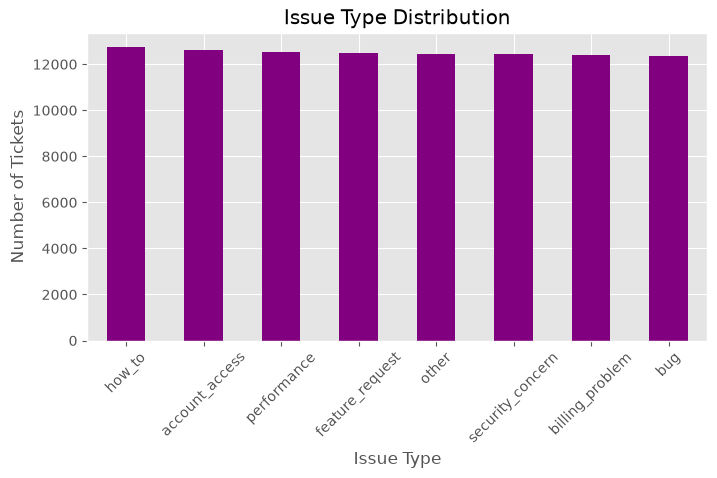

In [44]:
plt.figure(figsize=(8,4))

df["issue_type"].value_counts().plot(
    kind="bar",
    color="purple"
)

plt.title("Issue Type Distribution")
plt.xlabel("Issue Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)

plt.show()

# Insights

- Some issue types occur much more frequently than others
- Frequent issue categories require greater support resources
- Understanding issue patterns helps improve service planning

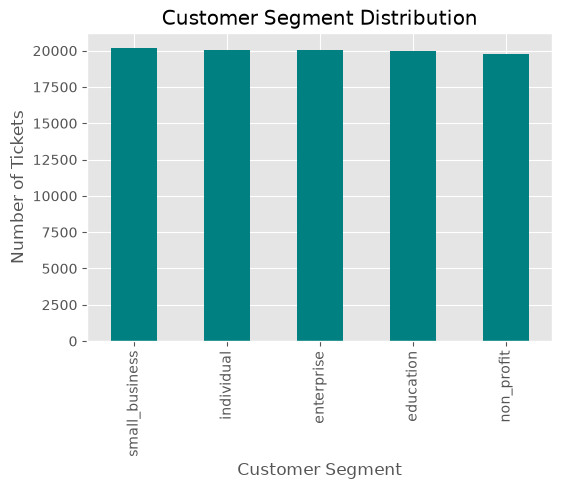

In [45]:
plt.figure(figsize=(6,4))

df["customer_segment"].value_counts().plot(
    kind="bar",
    color="teal"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Tickets")

plt.show()

# Insights

- Ticket volume varies across customer segments
- Some customer groups generate significantly more support requests
- Resource allocation can be optimized based on customer demand

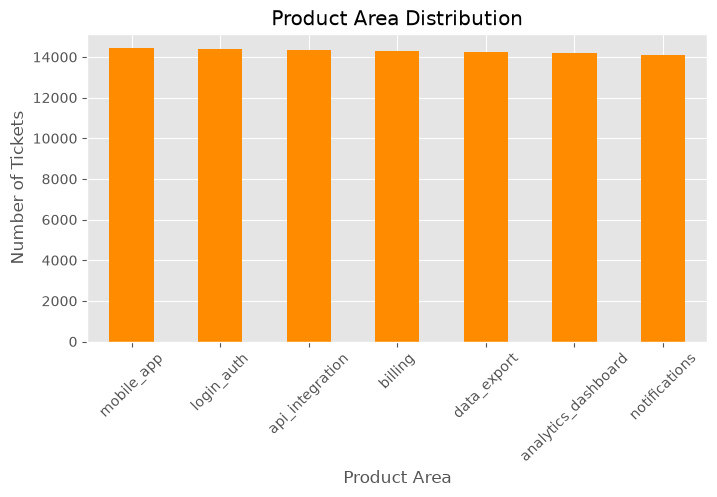

In [46]:
plt.figure(figsize=(8,4))

df["product_area"].value_counts().plot(
    kind="bar",
    color="darkorange"
)

plt.title("Product Area Distribution")
plt.xlabel("Product Area")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

# Insights
- Certain product areas generate the highest number of tickets
- These products may require additional maintenance and monitoring
- Product-wise analysis helps identify improvement opportunities

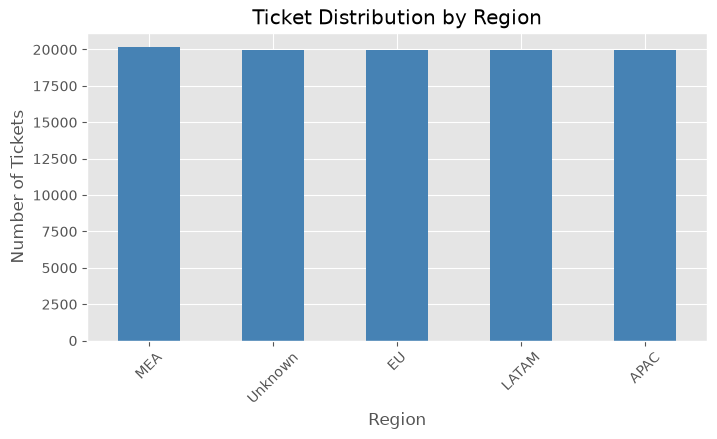

In [47]:
plt.figure(figsize=(8,4))

df["region"].value_counts().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Ticket Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

# Insights

- Ticket volume differs across geographical regions
- Some regions experience higher support demand
- Regional analysis assists in planning support resources


In [48]:
top_categories = df["issue_type"].value_counts().head(10)

print(top_categories)

issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64


In [49]:
cluster_frequency = df.groupby(["priority", "issue_type"]).size().reset_index(name="Count")

cluster_frequency = cluster_frequency.sort_values("Count", ascending=False)

cluster_frequency.head(10)

,priority,issue_type,Count
12,low,how_to,5055
13,low,other,5019
11,low,feature_request,4975
10,low,bug,4955
15,low,security_concern,4944
9,low,billing_problem,4931
14,low,performance,4929
8,low,account_access,4927
20,medium,how_to,4489
16,medium,account_access,4458


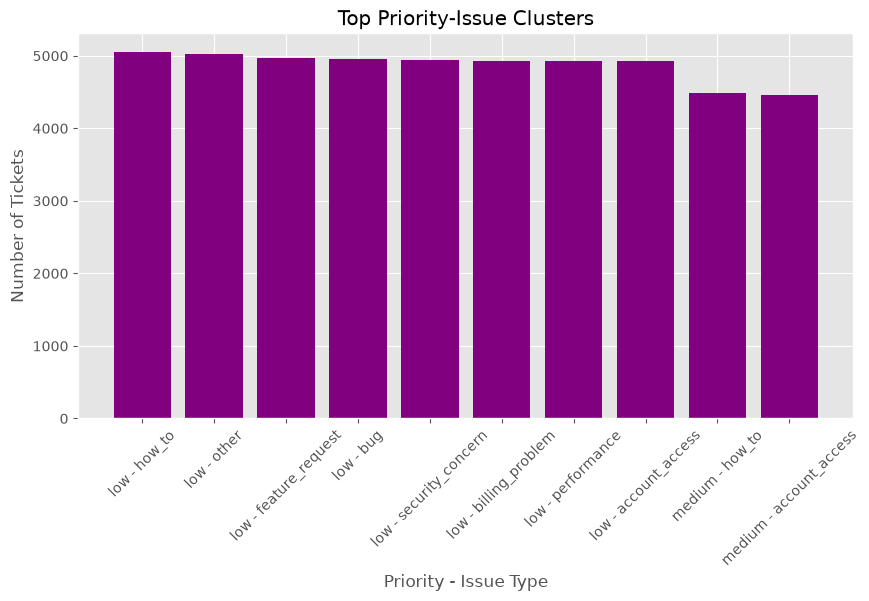

In [50]:
top_clusters = cluster_frequency.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_clusters["priority"] + " - " + top_clusters["issue_type"],
    top_clusters["Count"],
    color="purple"
)

plt.title("Top Priority-Issue Clusters")
plt.xlabel("Priority - Issue Type")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

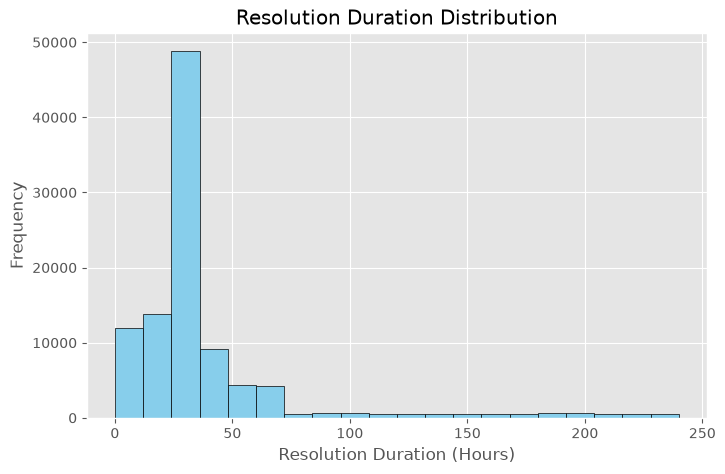

In [51]:
plt.figure(figsize=(8,5))

plt.hist(df["Resolution_Duration"], bins=20, color="skyblue", edgecolor="black")

plt.title("Resolution Duration Distribution")
plt.xlabel("Resolution Duration (Hours)")
plt.ylabel("Frequency")

plt.show()

# Insights

- Most tickets are resolved within a reasonable time
- A few tickets require significantly longer resolution
- Reducing long-resolution cases can improve efficiency

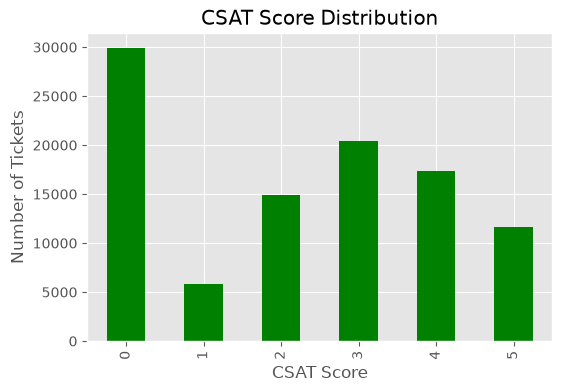

In [52]:
plt.figure(figsize=(6,4))

df["csat_score"].value_counts().sort_index().plot(
    kind="bar",
    color="green"
)

plt.title("CSAT Score Distribution")
plt.xlabel("CSAT Score")
plt.ylabel("Number of Tickets")

plt.show()

# Insights

- Customer satisfaction scores are generally positive
- Most customers report satisfactory service
- Maintaining quick resolution can further improve CSAT

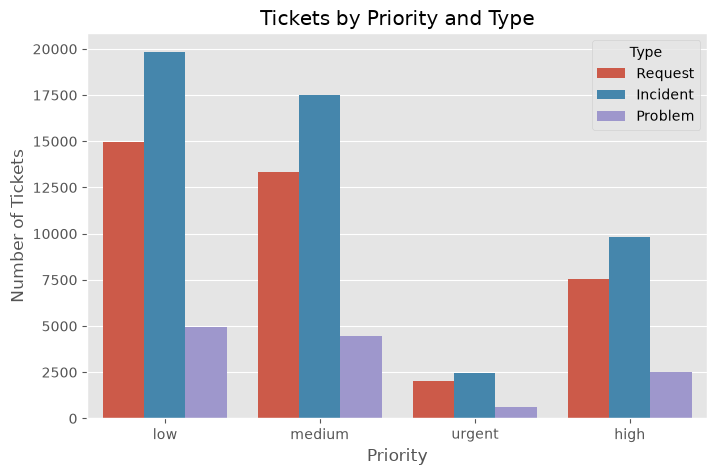

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="priority", hue="Type")

plt.title("Tickets by Priority and Type")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()

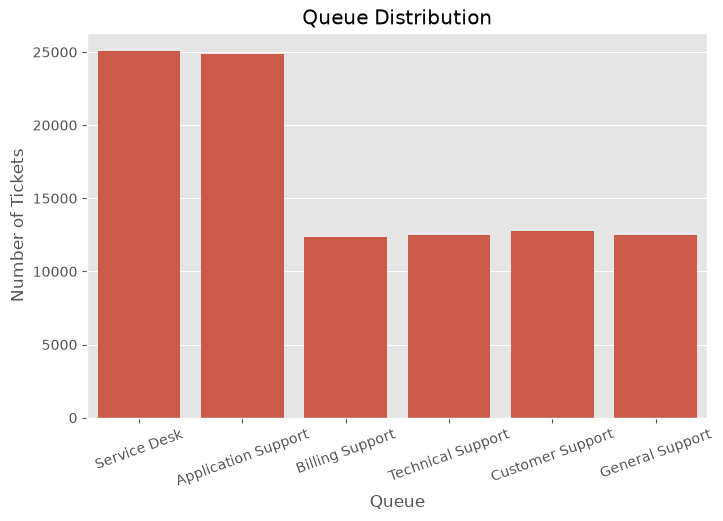

In [54]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Queue")
plt.title("Queue Distribution")
plt.xlabel("Queue")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)
plt.show()

# Insights

- Ticket workload is distributed across multiple support queues
- Some queues receive substantially more tickets
- Queue balancing can improve support efficiency

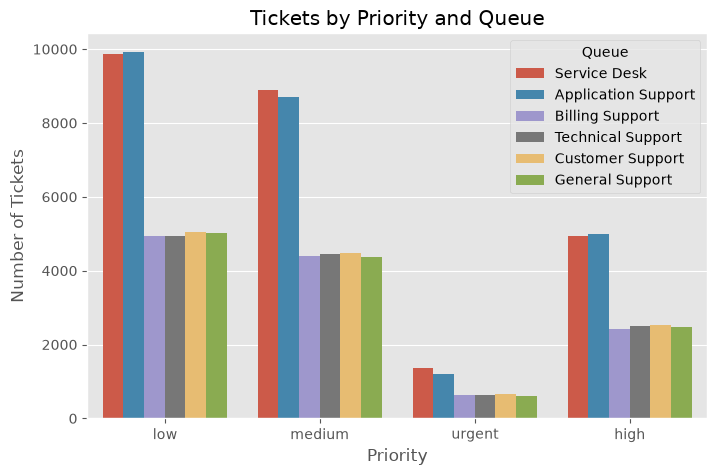

In [55]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="priority", hue="Queue")
plt.title("Tickets by Priority and Queue")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.show()

# Insights
-Ticket allocation varies across support queues
-High-priority tickets are handled by specialized queues
-Queue assignment follows ticket priority and issue type

# Module 4 - Similarity and Cluster Insights

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [57]:
features = ['csat_score', 'Priority_Score', 'Resolution_Duration', 'reopened']

In [58]:
df[features].isnull().sum()

csat_score             0
Priority_Score         0
Resolution_Duration    0
reopened               0
dtype: int64

In [59]:
df[features] = df[features].fillna(df[features].median())

In [60]:
X = df[features].copy()

In [61]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [62]:
silhouette_scores = {}

# Use a representative sample of 5000 records
X_sample = X_scaled[:5000]

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_sample)
    silhouette_scores[k] = silhouette_score(X_sample, labels)

silhouette_scores

{2: 0.5860316959100224,
 3: 0.3158273575724901,
 4: 0.3596360171628092,
 5: 0.40866348157087357,
 6: 0.4109463524609239,
 7: 0.43398536099893736,
 8: 0.433334760898726}

In [63]:
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans_final.fit_predict(X_scaled)

In [64]:
df["Cluster_ID"] = df["Cluster"] + 1

In [65]:
cluster_summary = df.groupby("Cluster_ID")[
    ["Priority_Score", "Resolution_Duration", "csat_score", "reopened"]
].mean().round(2)

cluster_summary

,Priority_Score,Resolution_Duration,csat_score,reopened
Cluster_ID,,,,
1,3.20,21.25,2.25,0.00
2,1.47,33.41,0.70,0.00
3,1.92,37.13,2.20,1.00
4,1.90,175.85,2.24,0.01
5,1.47,33.46,3.82,0.00


In [66]:
cluster_size = df["Cluster_ID"].value_counts().sort_index()

cluster_size

Cluster_ID
1    22258
2    33943
3     4990
4     5672
5    33137
Name: count, dtype: int64

In [67]:
cluster_names = {
    1: "High Priority - Fast Resolution",
    2: "Low Priority - Low CSAT",
    3: "Reopened Tickets",
    4: "Very Long Resolution",
    5: "High Satisfaction - Low Priority"
}

df["Cluster_Name"] = df["Cluster_ID"].map(cluster_names)

In [68]:
df[["Cluster_ID", "Cluster_Name"]].drop_duplicates().sort_values("Cluster_ID")

,Cluster_ID,Cluster_Name
6,1,High Priority - Fast Resolution
0,2,Low Priority - Low CSAT
15,3,Reopened Tickets
1,4,Very Long Resolution
2,5,High Satisfaction - Low Priority


In [69]:
cluster_size = (
    df.groupby(["Cluster_ID", "Cluster_Name"])
      .size()
      .reset_index(name="Ticket_Count")
      .sort_values("Cluster_ID")
)

cluster_size

,Cluster_ID,Cluster_Name,Ticket_Count
0,1,High Priority - Fast Resolution,22258
1,2,Low Priority - Low CSAT,33943
2,3,Reopened Tickets,4990
3,4,Very Long Resolution,5672
4,5,High Satisfaction - Low Priority,33137


In [70]:
cluster_size["Percentage"] = (
    cluster_size["Ticket_Count"] / len(df) * 100
).round(2)

cluster_size

,Cluster_ID,Cluster_Name,Ticket_Count,Percentage
0,1,High Priority - Fast Resolution,22258,22.26
1,2,Low Priority - Low CSAT,33943,33.94
2,3,Reopened Tickets,4990,4.99
3,4,Very Long Resolution,5672,5.67
4,5,High Satisfaction - Low Priority,33137,33.14


In [71]:
df.to_csv("IT_Support_Clustered.csv", index=False)

In [72]:
df[["ticket_id", "Cluster_ID", "Cluster_Name"]].head()

,ticket_id,Cluster_ID,Cluster_Name
0,TCKT_000001,2,Low Priority - Low CSAT
1,TCKT_000002,4,Very Long Resolution
2,TCKT_000003,5,High Satisfaction - Low Priority
3,TCKT_000004,5,High Satisfaction - Low Priority
4,TCKT_000005,2,Low Priority - Low CSAT


In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import numpy as np

In [74]:
features = df[[
    "Priority_Score",
    "Resolution_Duration",
    "csat_score",
    "reopened"
]]

features.head()

,Priority_Score,Resolution_Duration,csat_score,reopened
0,1,36.53,1,0
1,2,238.32,3,0
2,1,29.91,3,0
3,2,29.91,5,0
4,1,61.32,2,0


In [75]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features[:5]

array([[-1.01594874, -0.06327996, -0.70103703, -0.23050039],
       [ 0.10908309,  5.12971402,  0.42789252, -0.23050039],
       [-1.01594874, -0.2336433 ,  0.42789252, -0.23050039],
       [ 0.10908309, -0.2336433 ,  1.55682207, -0.23050039],
       [-1.01594874,  0.57468189, -0.13657225, -0.23050039]])

In [76]:
sample_features = scaled_features[:1000]
similarity_matrix = cosine_similarity(sample_features)
print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (1000, 1000)


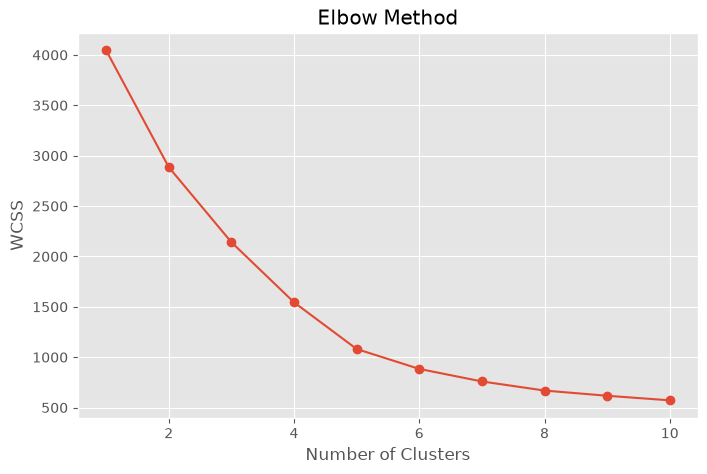

In [77]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(sample_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Insights
- The elbow curve indicates the optimal number of clusters
- Five clusters provide a good balance between accuracy and simplicity
- K-Means clustering is performed using K = 5

# Summary of Key Patterns and Problem Clusters

1. K-Means clustering grouped similar IT support tickets into five clusters based on Priority Score, Resolution Duration, CSAT Score, and Reopened status.
2. The elbow method indicated that five clusters provide a suitable balance between model simplicity and cluster quality.
3. Cluster analysis showed that some clusters contain more tickets than others, indicating that certain issue patterns occur more frequently.
4. The Cluster vs Issue Type visualization shows that different issue types are distributed across multiple clusters, helping identify dominant problem categories.
5. The Resolution Duration boxplot indicates that some clusters have significantly higher ticket resolution times, highlighting performance gaps.
6. The scatter plot between Resolution Duration and CSAT Score shows that customer satisfaction varies across clusters and resolution durations.
7. Similarity analysis confirms that tickets within the same cluster share similar characteristics, making clustering useful for identifying recurring support issues.
8. These insights can help IT support teams prioritize resources, improve response times, and identify recurring problems for proactive resolution.

 # Module 5 – Performance Trend Analysis

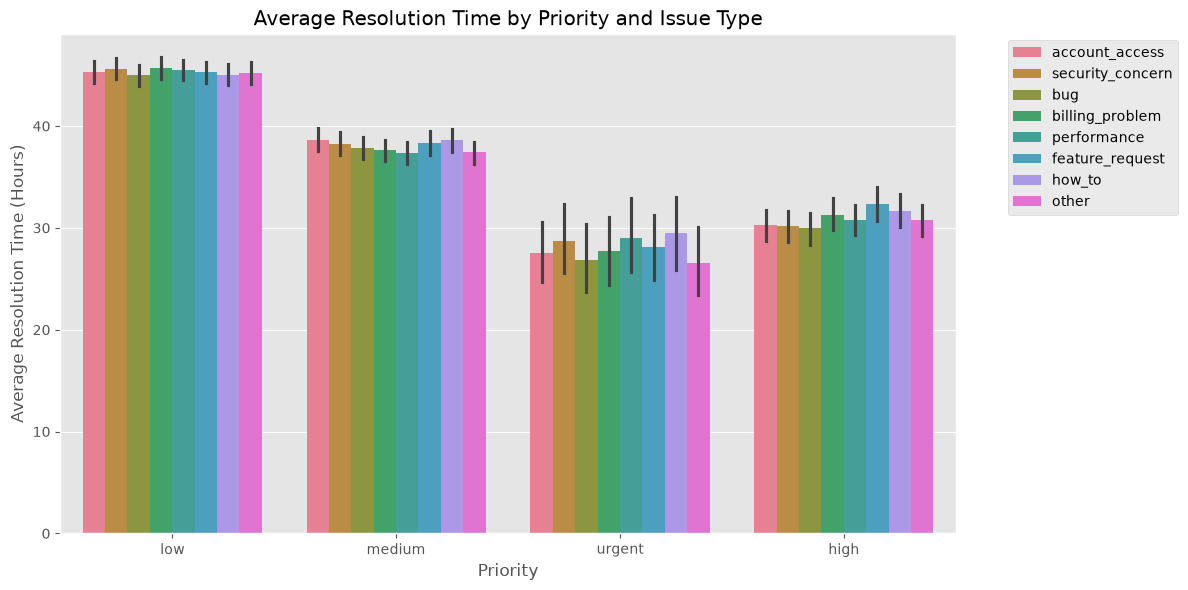

In [78]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="priority",
    y="Resolution_Duration",
    hue="issue_type"
)

plt.title("Average Resolution Time by Priority and Issue Type")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Time (Hours)")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# Insights
- Low-priority tickets take the longest average resolution time.
- Urgent tickets are resolved the fastest.
- Resolution time varies across issue types.
- Ticket priority influences overall resolution performance.

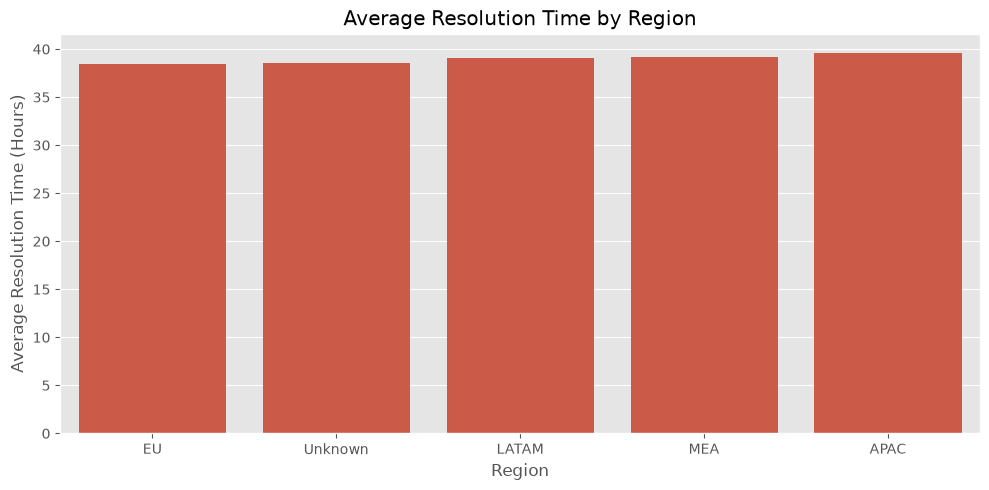

In [79]:
region_avg = (
    df.groupby("region")["Resolution_Duration"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=region_avg.index,
    y=region_avg.values
)

plt.title("Average Resolution Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Resolution Time (Hours)")
plt.tight_layout()
plt.show()

# Insights
- Average resolution time is similar across regions.
- No single region shows significantly slower performance.
- Regional support teams maintain relatively consistent resolution efficiency.

In [80]:
high_priority = df[
    (df["priority"]=="high") &
    (df["status"]!="resolved")
]

print(high_priority.shape)

(9920, 28)


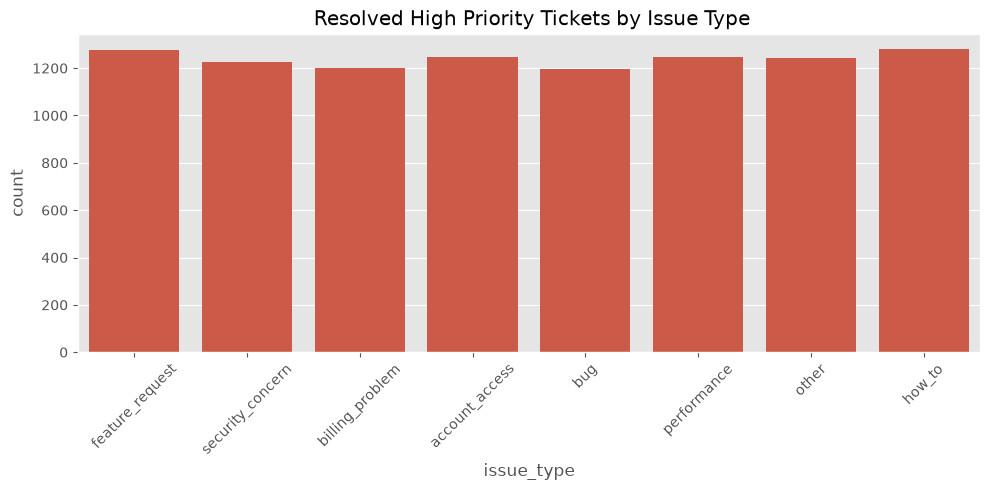

In [81]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=high_priority,
    x="issue_type"
)

plt.title(" Resolved High Priority Tickets by Issue Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insights
- High-priority unresolved tickets exist across all issue types.
- "How_to" and "Feature Request" categories have relatively more unresolved tickets.
- These issue types should be monitored to improve service quality.

# Module 6 – Geographic and Category-Level Insights

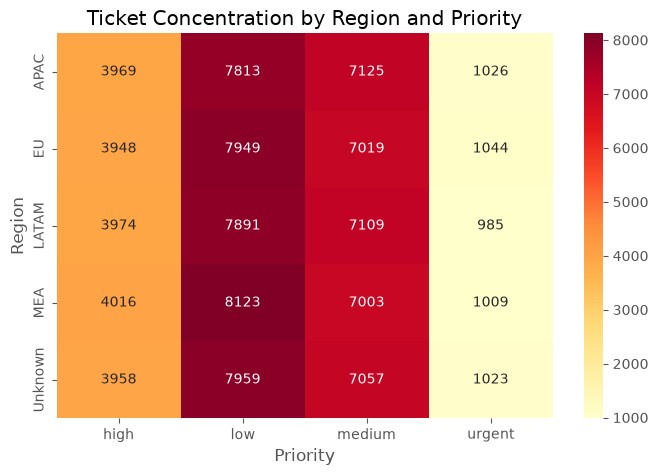

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

region_ticket = pd.crosstab(df["region"], df["priority"])

plt.figure(figsize=(8,5))

sns.heatmap(
    region_ticket,
    annot=True,
    fmt="d",
    cmap="YlOrRd"
)

plt.title("Ticket Concentration by Region and Priority")
plt.xlabel("Priority")
plt.ylabel("Region")

plt.show()

# Insights
- Low-priority tickets have the highest concentration across all regions.
- Urgent tickets are comparatively fewer.
- Ticket distribution is consistent across geographical regions.

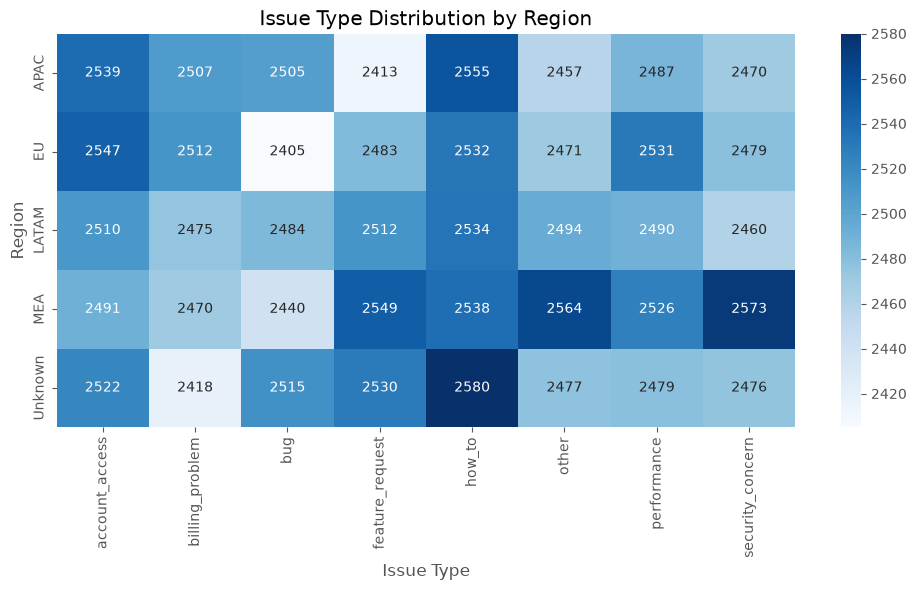

In [83]:
region_issue = pd.crosstab(df["region"], df["issue_type"])

plt.figure(figsize=(10,6))

sns.heatmap(
    region_issue,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Issue Type Distribution by Region")
plt.xlabel("Issue Type")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

# Insights
- All regions receive a similar mix of issue types.
- No issue type is concentrated in a single region.
- Ticket categories are evenly distributed geographically.

In [84]:
# Latitude mapping
latitude_map = {
    "APAC": -25,
    "EU": 54,
    "LATAM": -15,
    "MEA": 24,
    "Unknown": 0
}

# Longitude mapping
longitude_map = {
    "APAC": 133,
    "EU": 15,
    "LATAM": -60,
    "MEA": 45,
    "Unknown": 0
}

# Create new columns
df["Latitude"] = df["region"].map(latitude_map)
df["Longitude"] = df["region"].map(longitude_map)

# Check
df[["region", "Latitude", "Longitude"]].head()

,region,Latitude,Longitude
0,EU,54,15
1,Unknown,0,0
2,MEA,24,45
3,LATAM,-15,-60
4,Unknown,0,0
